# NL-3 aside — training a HOPE block

*A companion to [NL-3](nl3-hope.ipynb), built to answer one question: §5 assembled a HOPE block but only ran it* forward *— does the thing actually **learn**? This trains one end to end on a real task, small enough for a laptop CPU in a couple of minutes. Optional: read it when NL-3 §5 points here.*

Runs on CPU in ~3 minutes; pure PyTorch, no GPU. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/nested-learning/nl3-aside-training-hope.ipynb)

**The task: associative recall.** The model sees a list of key→value pairs, then a query key, and must output the matching value:

```
k₃ v₇  k₁ v₂  k₅ v₉  k₂ v₄   k₅     →     v₉
└────── pairs to store ──────┘  query    recall
```

This isolates exactly what HOPE is built for: **write associations into an in-context memory, then read one back.** A model with no memory cannot do it; HOPE should learn it to ~100% and even generalize to longer lists than it trained on.

It is the synthetic probe (MQAR) behind the *in-context recall* suite the paper reports in §9.4 — and a laptop-scale cousin of the needle-in-a-haystack tasks of §9.2, which are a different benchmark family (RULER) built on the same instinct.

> Reuses every piece of the course: the in-context store (M1), projections (M2), the delta/gated write (M4, NL-1), in-context $\eta,\alpha$ and the self-generated target (NL-3 §2), the DGD-flavored write (M6), a persistent feed-forward block (the $k$=1 single-frequency CMS — see the [continuum-memory aside](nl3-aside-continuum-memory.ipynb) for the real multi-frequency version), and — crucially — the **outer recall loss as the anchor** that keeps the self-generated target from collapsing (NL-3 §3). Plus a local convolution ([NL](https://arxiv.org/abs/2512.24695) §8.3).

## 1. The task — associative recall

Keys and values are tokens from two disjoint id ranges. A sequence interleaves $N$ pairs, then appends one of the keys as the query; the label is that key's value.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
NK, NV = 8, 12  # key-vocab and value-vocab sizes
VOCAB = NK + NV  # ids: keys in [0,NK), values in [NK, NK+NV)


def make_batch(B, N, gen):
    seqs, tgts = [], []
    for _ in range(B):
        keys = torch.randperm(NK, generator=gen)[:N]  # N distinct keys
        vals = torch.randint(0, NV, (N,), generator=gen)
        qi = torch.randint(0, N, (1,), generator=gen).item()  # which pair is queried
        s = []
        for i in range(N):
            s += [keys[i].item(), NK + vals[i].item()]  # key token, then value token
        s += [keys[qi].item()]  # final token = query key
        seqs.append(s)
        tgts.append(vals[qi].item())
    return torch.tensor(seqs), torch.tensor(tgts)


# show one example, decoded
seq, tgt = make_batch(1, 4, torch.Generator().manual_seed(2))
decode = lambda t: f"k{t}" if t < NK else f"v{t - NK}"
print("sequence:", " ".join(decode(t.item()) for t in seq[0]))
print("query is the last token; correct answer:", f"v{tgt.item()}")
print(f"chance accuracy = 1/NV = {1 / NV:.3f}")

sequence: k0 v7 k4 v8 k7 v3 k2 v6 k4
query is the last token; correct answer: v8
chance accuracy = 1/NV = 0.083


## 2. The model — a trainable HOPE block

This is [NL-3](nl3-hope.ipynb) §5's block, made trainable and given the two things a real recall model needs: a **local causal convolution** (§8.3 uses a window of 4) so a value position can "see" the key just before it — without this the per-token memory only ever binds a token to *itself* and can't link key→value across positions — and an **outer cross-entropy loss** on the recalled value, which trains all the slow weights *and* anchors the self-generated target (NL-3 §3).

In [3]:
class HopeRecall(nn.Module):
    def __init__(self, d=48, memory=True):
        super().__init__()
        self.d = d
        self.memory = memory
        self.emb = nn.Embedding(VOCAB, d)
        self.conv = nn.Conv1d(d, d, 4, groups=d, padding=3)  # depthwise causal, window 4 (HOPE §8.3)
        self.Wk, self.Wv, self.Wq = (nn.Linear(d, d, bias=False) for _ in range(3))  # projections (M2)
        self.g_eta, self.g_alpha = nn.Linear(d, 1), nn.Linear(d, 1)  # in-context η,α (NL-1/NL-3 §2)
        self.Mv = nn.Linear(d, d, bias=False)  # self-generated target (NL-3 §2)
        self.cms = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, d))  # persistent FFN: the k=1 single-frequency CMS (= a plain MLP)
        self.head = nn.Linear(d, NV)

    def forward(self, seq):
        B, L = seq.shape
        d = self.d
        x = self.emb(seq)
        x = x + self.conv(x.transpose(1, 2))[:, :, :L].transpose(1, 2)  # mix adjacent tokens
        M = torch.zeros(B, d, d) # fast in-context memory (M1)
        o = torch.zeros(B, d)  
        for t in range(L):
            xt = x[:, t]
            k, v, q = self.Wk(xt), self.Wv(xt), self.Wq(xt)
            k, q = F.normalize(k, dim=-1), F.normalize(q, dim=-1)  # L2-normalize k,q (HOPE §8.3)
            if not self.memory:
                o = self.cms(q)
                continue  # ablation: no in-context memory
            target = self.Mv(v)  # self-generated target (anchored by outer loss)
            eta = torch.sigmoid(self.g_eta(xt)).unsqueeze(-1)  # in-context learning rate
            alpha = torch.sigmoid(self.g_alpha(xt)).unsqueeze(-1)  # in-context forget gate
            Mk = torch.bmm(M, k.unsqueeze(-1)).squeeze(-1)
            M = alpha * M - eta * torch.bmm((Mk - target).unsqueeze(-1), k.unsqueeze(1))  # gated delta write
            o = torch.bmm(M, q.unsqueeze(-1)).squeeze(-1)  # read with the query key
        return self.head(self.cms(o))


print("HopeRecall defined — every line traces to a module (see the comments).")

HopeRecall defined — every line traces to a module (see the comments).


## 3. Train it

Plain supervised training: cross-entropy on the recalled value, Adam on all parameters. The outer loop trains the slow weights (projections, gates, $\mathcal M_v$, the feed-forward block, head); the **fast** memory $M$ is written in-context inside each forward pass and reset per sequence. (A couple of minutes on CPU.)

In [4]:
def train(memory, steps, N=4, B=64, lr=3e-3, seed=1):
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    model = HopeRecall(memory=memory)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    curve = []
    for s in range(steps):
        seq, tgt = make_batch(B, N, gen)
        loss = F.cross_entropy(model(seq), tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if s % 100 == 0:
            curve.append((s, loss.item()))
    return model, curve


hope_model, hope_curve = train(memory=True, steps=700)
print("training done. loss every 100 steps:")
for s, l in hope_curve:
    print(f"  step {s:>4}: loss {l:.3f}")

training done. loss every 100 steps:
  step    0: loss 2.484
  step  100: loss 0.863
  step  200: loss 0.005
  step  300: loss 0.000
  step  400: loss 0.000
  step  500: loss 0.000
  step  600: loss 0.000


## 4. Did it learn? — accuracy, the loss curve, and an ablation

In [5]:
def accuracy(model, N, n=512, seed=999):
    with torch.no_grad():
        seq, tgt = make_batch(n, N, torch.Generator().manual_seed(seed))
        return (model(seq).argmax(-1) == tgt).float().mean().item()


# ablation: same block with the in-context memory DISABLED
mem_off, _ = train(memory=False, steps=500)

print(f"chance                         : {1 / NV:.3f}")
print(f"HOPE (in-context memory)       : {accuracy(hope_model, 4):.3f}")
print(f"memory DISABLED (conv only)    : {accuracy(mem_off, 4):.3f}")

chance                         : 0.083
HOPE (in-context memory)       : 1.000
memory DISABLED (conv only)    : 0.320


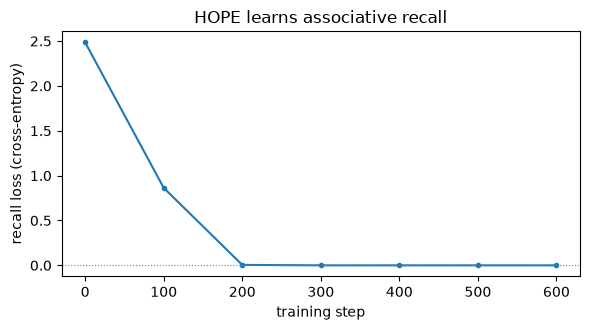

In [6]:
import matplotlib.pyplot as plt

steps, losses = zip(*hope_curve)
plt.figure(figsize=(6, 3.4))
plt.plot(steps, losses, "-o", ms=3)
plt.axhline(0, color="gray", lw=0.8, ls=":")
plt.xlabel("training step")
plt.ylabel("recall loss (cross-entropy)")
plt.title("HOPE learns associative recall")
plt.tight_layout()
plt.show()

HOPE reaches **~100%** recall (loss → 0); the **memory-disabled** ablation stalls far lower — the local conv lets it catch a query about the *most recent* pair (a recency shortcut), but only the **in-context memory** can recall an *arbitrary* earlier pair. The memory is doing the work the whole course built toward — and the **outer recall loss is exactly the anchor of [NL-3](nl3-hope.ipynb) §3**: the self-generated target $\hat{\mathbf v}=\mathcal M_v(\mathbf v)$ doesn't collapse here because it is wrapped in a loss that scores real recall.

## 5. It generalizes to longer contexts than it trained on

The model trained on **4 pairs**. A recurrent in-context memory should handle *more* pairs at test time without retraining — the same write rule just runs for more steps. This is the small-scale shadow of HOPE's long-context result (holding recall far past the trained length).

In [7]:
print("trained on N=4 pairs; tested on longer sequences (no retraining):")
for N in [4, 6, 8]:
    print(f"  N={N} pairs  (seq len {2*N+1}):  recall acc {accuracy(hope_model, N):.3f}")

trained on N=4 pairs; tested on longer sequences (no retraining):
  N=4 pairs  (seq len 9):  recall acc 1.000
  N=6 pairs  (seq len 13):  recall acc 1.000
  N=8 pairs  (seq len 17):  recall acc 1.000


## 6. Watch one recall happen

In [8]:
seq, tgt = make_batch(1, 4, torch.Generator().manual_seed(123))
with torch.no_grad():
    pred = hope_model(seq).argmax(-1).item()
decode = lambda t: (f"k{t}" if t < NK else f"v{t-NK}")
print("sequence :", " ".join(decode(t.item()) for t in seq[0]))
print(f"query key: {decode(seq[0,-1].item())}")
print(f"HOPE says: v{pred}    correct: v{tgt.item()}    {'✓' if pred==tgt.item() else '✗'}")

sequence : k6 v5 k2 v11 k1 v10 k3 v11 k2
query key: k2
HOPE says: v11    correct: v11    ✓


## What this shows

- **HOPE trains end to end on a real task** with ordinary backprop, and solves associative recall to ~100% — the in-context memory writes pair associations during the forward pass and reads the right one back at the query.
- **The pieces matter, concretely:** disable the memory and recall collapses to a recency shortcut; the local conv is what lets a value position bind to the preceding key; L2-normalized keys keep the writes from crosstalking (the [linear-algebra primer](../../primers/linear-algebra.ipynb); M1's capacity law).
- **The anchor is real:** the self-generated target $\hat{\mathbf v}=\mathcal M_v(\mathbf v)$ trains fine *because* the outer recall loss supervises it — no collapse, exactly as [NL-3](nl3-hope.ipynb) §3 argued.
- **Recurrence generalizes:** trained on 4 pairs, it recalls from longer lists unchanged — the laptop-scale shadow of HOPE's long-context behavior.

**Honest scope.** This is a deliberately tiny instance: a single matrix memory (not a deep MLP memory), a single feed-forward block trained as an ordinary slow weight — the $k$=1 single-frequency CMS (a plain MLP), **not** the real multi-frequency continuum (built in the [continuum-memory aside](nl3-aside-continuum-memory.ipynb)) — full BPTT over short sequences (not the chunk-wise parallel training HOPE uses at scale, §8.2), and a synthetic task. It demonstrates that the assembled block *trains and works*, and that each ingredient earns its place — not the paper's full-scale results.

**Things to tinker with:** raise `NK`/`N` until recall degrades (you've hit the single matrix memory's capacity — M1's effective-rank limit); turn off the conv and watch recall fall to the recency shortcut; swap the self-generated target `self.Mv(v)` for the raw value `v` and compare; print `eta`/`alpha` per token to see the in-context update rule vary ([NL-3](nl3-hope.ipynb) §2).